# Task 2: Unemployment Analysis in India

Analyze India's unemployment rate data, the impact of COVID-19, regional differences, and seasonal patterns.

## 1. Load the Data

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv('Unemployment_in_India.csv')
df.columns = df.columns.str.strip()  # remove extra whitespace from column names

print(df.columns.tolist())
print(df.shape)
df.head()

['Region', 'Date', 'Frequency', 'Estimated Unemployment Rate (%)', 'Estimated Employed', 'Estimated Labour Participation Rate (%)', 'Area']
(768, 7)

           Region          Date Frequency  Estimated Unemployment Rate (%)  Estimated Employed  Estimated Labour Participation Rate (%)   Area
0  Andhra Pradesh    31-05-2019   Monthly                              3.65          11999139.0                                     43.24  Rural
1  Andhra Pradesh    30-06-2019   Monthly                              3.05          11755881.0                                     42.05  Rural
2  Andhra Pradesh    31-07-2019   Monthly                              3.75          12086707.0                                     43.50  Rural
3  Andhra Pradesh    31-08-2019   Monthly                              3.32          12285693.0                                     43.97  Rural
4  Andhra Pradesh    30-09-2019   Monthly                              3.95          12256762.0                                

The dataset has **768 rows** covering **28 regions** in India, from **May 2019 to June 2020**.

## 2. Data Cleaning

In [ ]:
df.isnull().sum()

Region                                      28
Date                                        28
Frequency                                   28
Estimated Unemployment Rate (%)             28
Estimated Employed                          28
Estimated Labour Participation Rate (%)     28
Area                                        28
dtype: int64


In [ ]:
# Drop fully empty rows
df = df.dropna()

# Strip whitespace from text columns
for col in df.select_dtypes(include='object').columns:
    df[col] = df[col].str.strip()

# Convert Date column to datetime
df['Date'] = pd.to_datetime(df['Date'], dayfirst=True)

print("Shape after cleaning:", df.shape)
print("Date range:", df['Date'].min(), "to", df['Date'].max())
print("Number of regions:", df['Region'].nunique())
print("Areas:", df['Area'].unique())

Shape after cleaning: (740, 7)
Date range: 2019-05-31 00:00:00 to 2020-06-30 00:00:00
Number of regions: 28
Areas: ['Rural' 'Urban']


There were **28 fully empty rows**, removed during cleaning, leaving **740 valid rows**.

## 3. Descriptive Statistics

In [ ]:
df['Estimated Unemployment Rate (%)'].describe()

count    740.000000
mean      11.787946
std       10.721298
min        0.000000
25%        4.657500
50%        8.350000
75%       15.887500
max       76.740000
Name: Estimated Unemployment Rate (%), dtype: float64


The standard deviation is very high (10.72) relative to the median (8.35), indicating large variation between regions and time periods — especially during the COVID period.

## 4. Overall Unemployment Trend Over Time

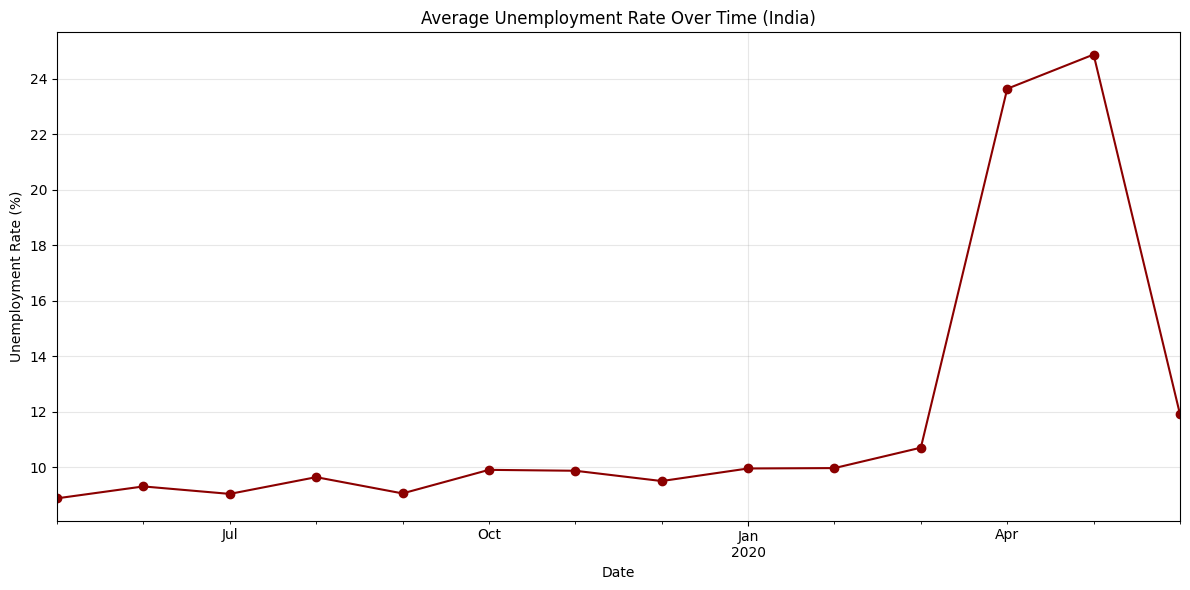

In [ ]:
overall = df.groupby('Date')['Estimated Unemployment Rate (%)'].mean()

plt.figure(figsize=(12, 6))
overall.plot(marker='o', color='darkred')
plt.title('Average Unemployment Rate Over Time (India)')
plt.ylabel('Unemployment Rate (%)')
plt.xlabel('Date')
plt.grid(alpha=0.3)
plt.show()

The rate stayed relatively stable around **8-10%** through 2019, then spiked dramatically in **April 2020**.

## 5. COVID-19 Impact

In [ ]:
covid_period = df[df['Date'] >= '2020-03-01']
pre_covid = df[df['Date'] < '2020-03-01']

pre_avg = pre_covid['Estimated Unemployment Rate (%)'].mean()
covid_avg = covid_period['Estimated Unemployment Rate (%)'].mean()

print(f"Pre-COVID avg unemployment rate:  {pre_avg:.2f}%")
print(f"During/Post-COVID avg rate:       {covid_avg:.2f}%")
print(f"Increase:                          {covid_avg - pre_avg:.2f} percentage points")

Pre-COVID avg unemployment rate:  9.51%
During/Post-COVID avg rate:       17.77%
Increase:                          8.26 percentage points


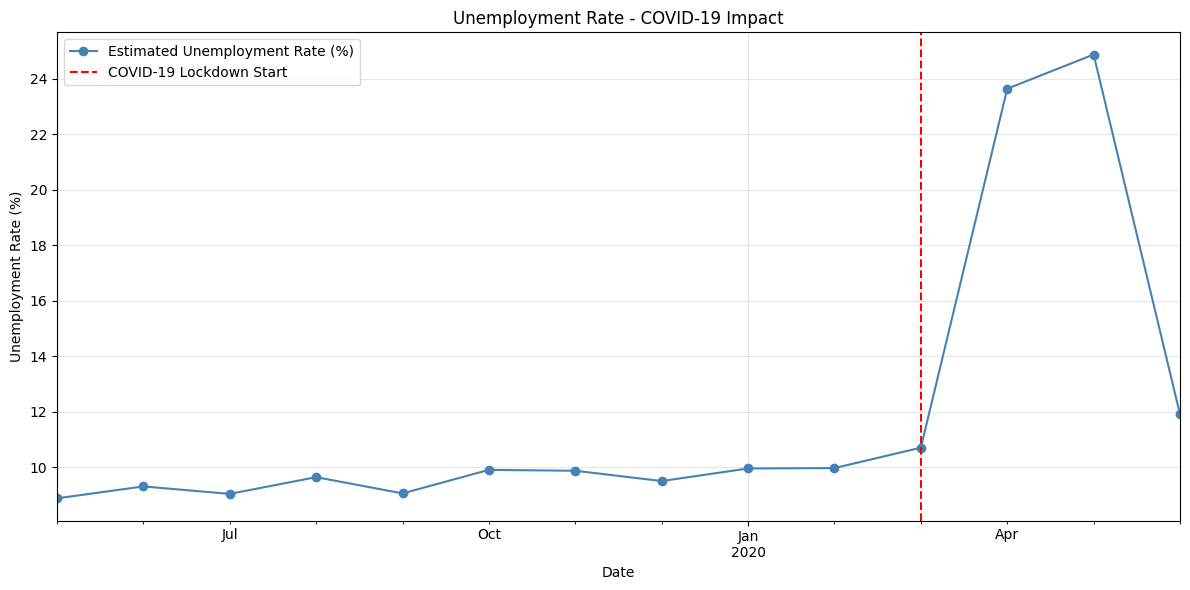

In [ ]:
plt.figure(figsize=(12, 6))
overall.plot(marker='o', color='steelblue')
plt.axvline(pd.to_datetime('2020-03-01'), color='red', linestyle='--', label='COVID-19 Lockdown Start')
plt.title('Unemployment Rate - COVID-19 Impact')
plt.ylabel('Unemployment Rate (%)')
plt.xlabel('Date')
plt.legend()
plt.grid(alpha=0.3)
plt.show()

**Key finding:** the COVID-19 lockdown nearly **doubled** India's average unemployment rate within a few months.

## 6. Analysis by Region

In [ ]:
region_avg = df.groupby('Region')['Estimated Unemployment Rate (%)'].mean().sort_values(ascending=False)
region_avg.head(10)

Region
Tripura             28.350357
Haryana             26.283214
Jharkhand           20.585000
Bihar               18.918214
Himachal Pradesh    18.540357
Delhi               16.495357
Jammu & Kashmir     16.188571
Chandigarh          15.991667
Rajasthan           14.058214
Uttar Pradesh       12.551429
Name: Estimated Unemployment Rate (%), dtype: float64


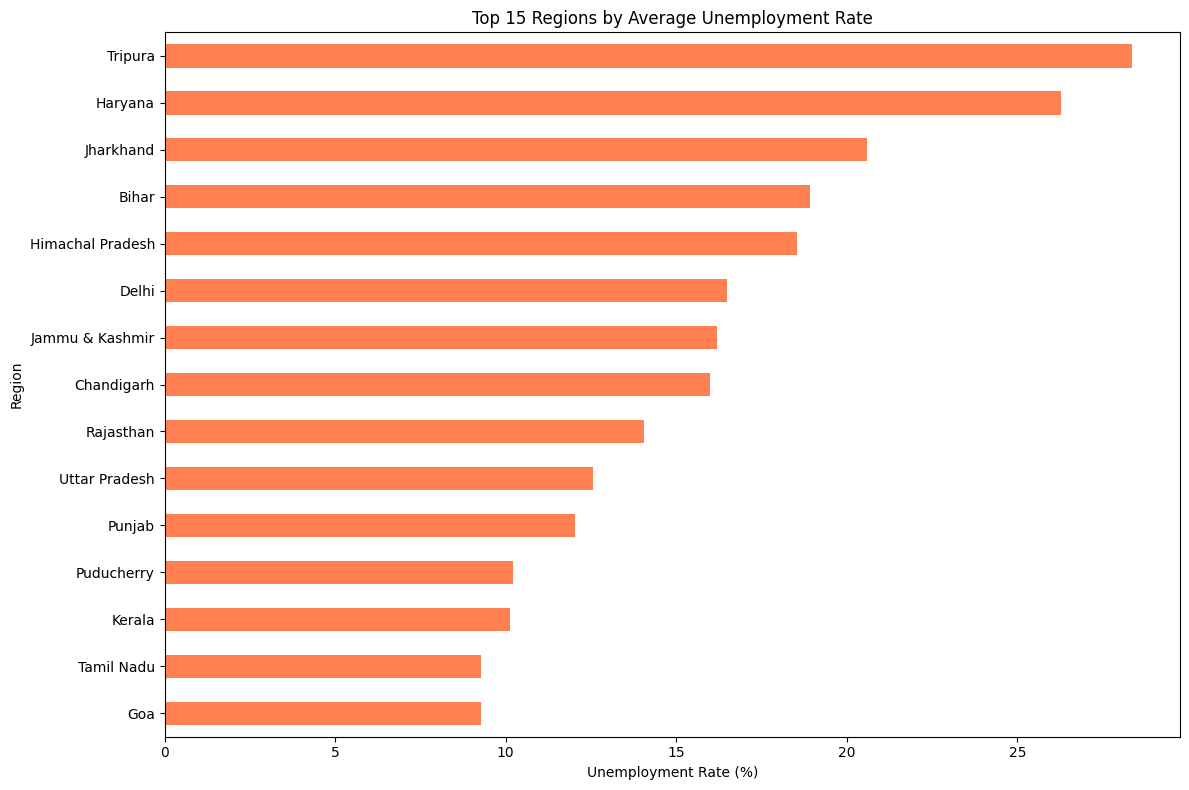

In [ ]:
plt.figure(figsize=(12, 8))
region_avg.head(15).plot(kind='barh', color='coral')
plt.title('Top 15 Regions by Average Unemployment Rate')
plt.xlabel('Unemployment Rate (%)')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

**Lowest unemployment region:** Meghalaya (4.80%)\n\n**Highest unemployment region:** Tripura (28.35%) — about **6x higher** than the lowest.

## 7. Urban vs. Rural

In [ ]:
area_avg = df.groupby('Area')['Estimated Unemployment Rate (%)'].mean()
area_avg

Area
Rural    10.324791
Urban    13.166614
Name: Estimated Unemployment Rate (%), dtype: float64


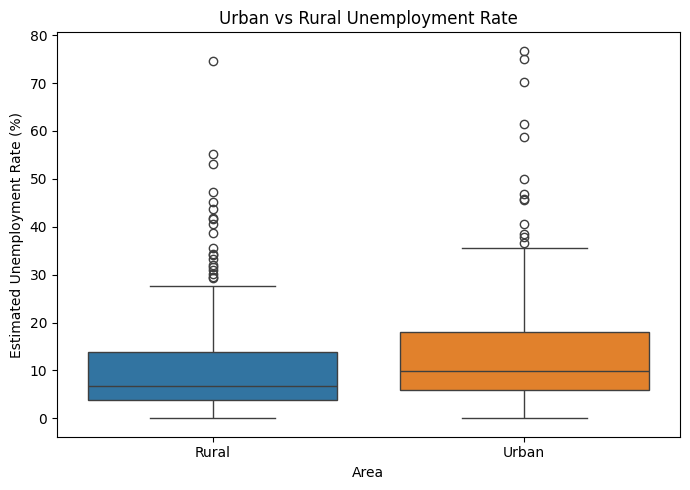

In [ ]:
plt.figure(figsize=(7, 5))
sns.boxplot(data=df, x='Area', y='Estimated Unemployment Rate (%)')
plt.title('Urban vs Rural Unemployment Rate')
plt.tight_layout()
plt.show()

**Urban areas** have a noticeably higher unemployment rate than **rural areas** (13.17% vs 10.32%), likely because rural economies absorb labor more broadly through agriculture and seasonal work.

## 8. Seasonal Patterns

In [ ]:
df['Month'] = df['Date'].dt.month

monthly_avg = df.groupby('Month')['Estimated Unemployment Rate (%)'].mean()
monthly_avg

Month
1      9.950755
2      9.964717
3     10.700577
4     23.641569
5     16.646190
6     10.553462
7      9.033889
8      9.637925
9      9.051731
10     9.900909
11     9.868364
12     9.497358
Name: Estimated Unemployment Rate (%), dtype: float64


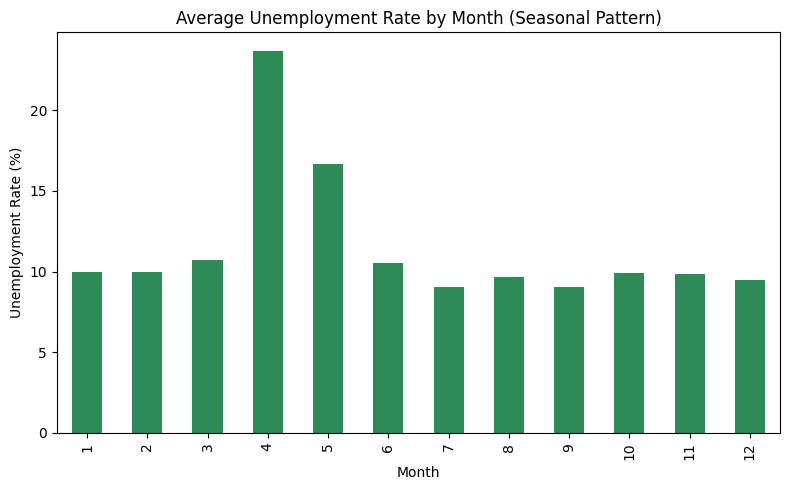

In [ ]:
monthly_avg.plot(kind='bar', color='seagreen', figsize=(8,5))
plt.title('Average Unemployment Rate by Month (Seasonal Pattern)')
plt.xlabel('Month')
plt.ylabel('Unemployment Rate (%)')
plt.tight_layout()
plt.show()

**April** stands out sharply (23.64%) compared to ~9-10% in other months. This spike is driven by the **nationwide lockdown** in April 2020 rather than a recurring annual seasonal pattern (the dataset only fully covers one year).

## 9. Employment and Labour Participation Over Time

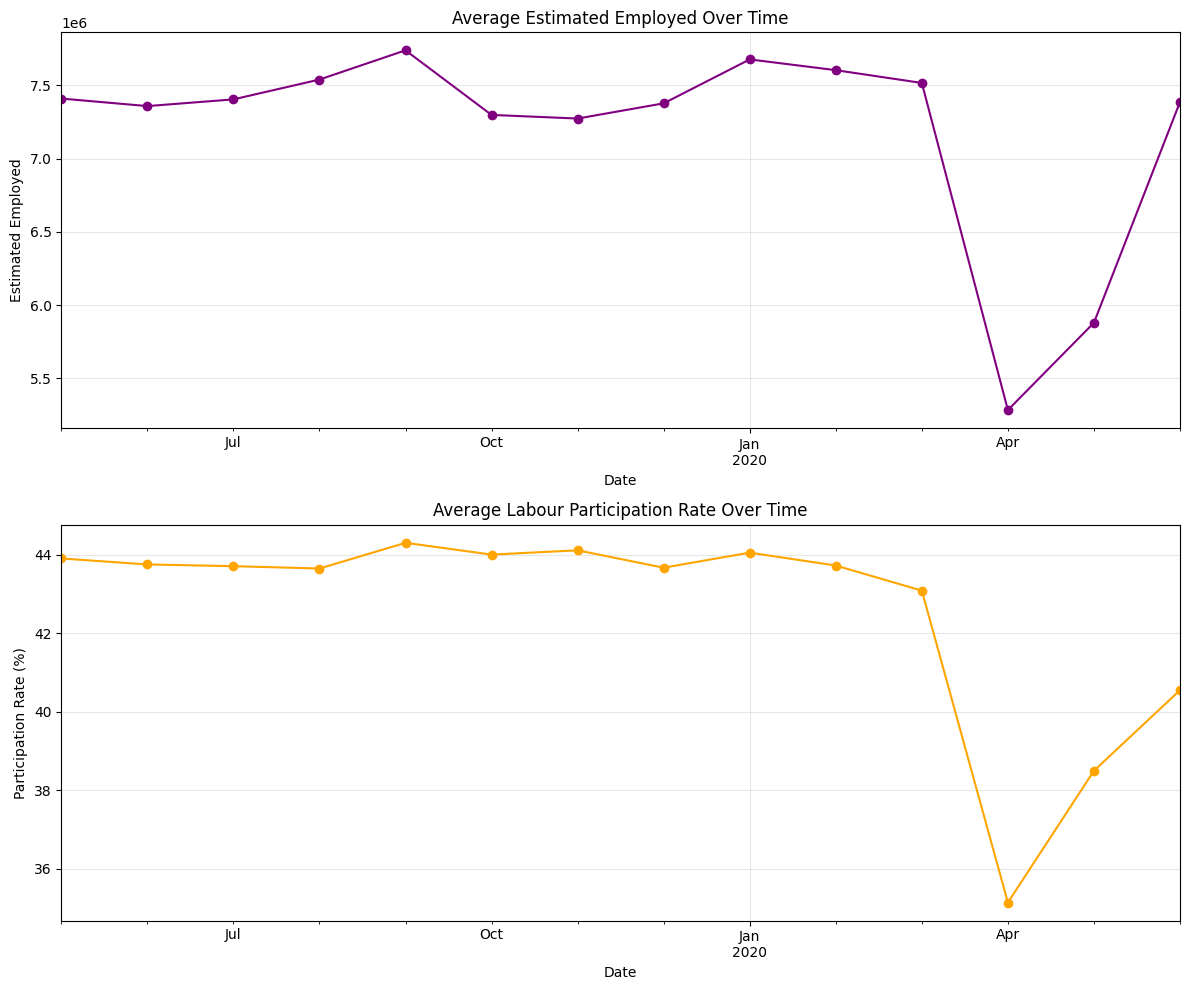

In [ ]:
fig, axes = plt.subplots(2, 1, figsize=(12, 10))

df.groupby('Date')['Estimated Employed'].mean().plot(ax=axes[0], color='purple', marker='o')
axes[0].set_title('Average Estimated Employed Over Time')
axes[0].grid(alpha=0.3)

df.groupby('Date')['Estimated Labour Participation Rate (%)'].mean().plot(ax=axes[1], color='orange', marker='o')
axes[1].set_title('Average Labour Participation Rate Over Time')
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

Both **employment levels** and **labour participation rate** drop sharply in the same April 2020 window — consistent with the unemployment spike.

## Key Insights / Summary

1. **COVID-19 impact is large and clear**: the unemployment rate jumped from **9.51%** to **17.77%** (+8.26 points) after March 2020.
2. **April 2020** was by far the worst month (23.64%) — direct effect of the nationwide lockdown.
3. **Large regional disparity**: from 4.80% (Meghalaya) to 28.35% (Tripura) — almost a 6x gap.
4. **Urban areas hit harder than rural**: 13.17% vs 10.32%.
5. **Gradual recovery**: the rate fell from May (16.65%) to June (10.55%) but had not fully returned to pre-COVID levels.

### Policy Implications
- Target employment support programs at the most affected regions (Tripura, Haryana, Jharkhand).
- Provide targeted support for urban sectors, which are more sensitive to lockdowns.
- Build an early-warning system based on monthly data to detect future spikes quickly.